# Notebook 13 — Advanced Spatial Privacy Evaluation Part 2
## Density Surfaces, Multi-scale Analysis, and the Privacy–Utility Frontier

NB12 (Part 1) evaluated point pattern structure via Ripley's K, Moran's I,
and Getis-Ord Gi*. This notebook continues with **surface-level** and
**system-level** metrics:

| Section | Metric | Question |
|---------|--------|----------|
| 13.1 | KDE fidelity | Does the density surface shape survive jitter? |
| 13.2 | Multi-scale K sweep | How does clustering preservation degrade as jitter increases? |
| 13.3 | Privacy–utility frontier | What is the Pareto-optimal tradeoff curve? |
| 13.4 | Failure cases | Where do metrics disagree with each other? |

<div style="background:#f5faf9;border:1px solid #b8ddd8;border-radius:8px;padding:12px 14px 14px;margin:10px 0 22px;font-family:sans-serif;">
<div style="font-size:11px;color:#5a9e99;margin-bottom:10px;font-style:italic;">Advanced spatial evaluation of the complete pipeline (Part 2)</div>
<div style="display:flex;align-items:stretch;">
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:0;position:relative;z-index:4;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB02</div><div style="font-weight:700;font-size:13px;">① Project</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:3;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB03</div><div style="font-weight:700;font-size:13px;">② Snap+Shuffle</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:2;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB04</div><div style="font-weight:700;font-size:13px;">③ Lock</div></div>
    <div style="background:#2a9d8f;color:white;padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:1;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB05</div><div style="font-weight:700;font-size:13px;">④ Wobble</div></div>
</div>
</div>

## Learning Objectives

By the end of this notebook you will be able to:

1. **Define** KDE surface fidelity and identify the two metrics used to quantify it — Pearson r and KL divergence.
2. **Interpret** the privacy–utility frontier curve and describe the tradeoff it represents between EDD and utility-metric preservation.
3. **Apply** the linked DualMap visualisation to compare original and jitter-displaced density surfaces interactively.
4. **Examine** how AUC-L clustering preservation degrades as `jitter_max_frac` increases from 0 to 0.5 and identify the inflection point.
5. **Critique** the three failure cases and explain why relying on any single metric can produce misleading conclusions about privacy or utility.

## Setup

In [1]:
import sys; sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
import folium
import folium.plugins as fp
import libpysal, esda
from pointpats.distance_statistics import k_test
from scipy.stats import gaussian_kde
from map_encryption import MapEncryption, SchemeParams, _project, _unproject

CENTER_LAT, CENTER_LON = 51.513341, -0.136668

# ── Data: 489 individual cholera deaths at 250 unique address locations ────────
# The primary source is cholera_deaths_individual.csv (one row per death).
# Spatial statistics operate on the 250 unique address locations; deaths at the
# same address are represented as a count (DEATHS = 1–15) rather than as
# duplicate coordinates. Placing 489 individual records at exactly the same
# projected coordinates would inflate Ripley's K at distance ~= 0 and bias the
# L-function at short ranges -- a co-location artefact, not geographic structure.
# The 489 individual records are the primary unit from NB14 onward.
_deaths_ind = pd.read_csv('data/cholera_deaths_individual.csv')
deaths = (_deaths_ind
          .groupby('FID', as_index=False)
          .agg(DEATHS=('DEATHS', 'sum'),
               LAT=('LAT_ORIG', 'first'),
               LON=('LON_ORIG', 'first')))

# Project unique address locations to Web Mercator metres
xy_orig  = np.array([_project(r.LAT, r.LON) for _, r in deaths.iterrows()])
y_death  = deaths['DEATHS'].values.astype(float)

_n_ind = int(_deaths_ind['DEATHS'].sum())
print(f'{_n_ind} individual cholera deaths at {len(deaths)} unique address locations')
print(f'Deaths per address: min={int(y_death.min())}, max={int(y_death.max())}, mean={y_death.mean():.2f}')
print('All spatial statistics use the 250 unique address locations.')

# Baseline jitter-only (J = +-62.5 m, matching jitter_max_frac=0.25)
J_BASE = 250 * 0.25
rng = np.random.default_rng(seed=42)
xy_jit = xy_orig + rng.uniform(-J_BASE, J_BASE, xy_orig.shape)

print(f'Baseline jitter: +-{J_BASE:.0f} m per axis')


489 individual cholera deaths at 250 unique address locations
Deaths per address: min=1, max=15, mean=1.96
All spatial statistics use the 250 unique address locations.
Baseline jitter: +-62 m per axis


> **Data note — 489 individual deaths, 250 unique address locations.**
>
> The 1854 Soho cholera dataset records **489 individual deaths** at **250 unique
> address locations** (doorways / households), with 1–15 deaths per address
> depending on household size and duration of exposure.
>
> All spatial statistics in this notebook (Ripley's K / L-function, KDE,
> Moran's I, Gi*) use the **250 unique address locations** as point events.
> Using all 489 individual records directly would place multiple deaths at
> exactly the same projected coordinate — a co-location artefact that inflates
> K(t) at distance ≈ 0 and biases the L-function at short ranges. The death
> count at each address (1–15) serves as the **mark attribute** in Moran's I and
> Gi*, so high-death addresses contribute proportionally to autocorrelation and
> hotspot detection.
>
> From NB14 onward, the 489 individual records (`cholera_deaths_individual.csv`)
> are used directly for individual-level privacy risk analysis.


In [2]:
# Set True to re-run all heavy computations and overwrite cached files.
# Set False (default) to load precomputed results — much faster on Binder.
RECOMPUTE = False


## Part 1 — KDE Surface Fidelity

Kernel Density Estimation (KDE) converts a point pattern into a continuous
density surface. For disease mapping, the surface shape conveys where risk
is concentrated. Jitter displaces points; the question is how much the
surface *shape* changes.

Three similarity measures are computed on a 60 × 60 grid over the Soho study area:

- **Pearson r** — linear correlation between original and jittered density values
- **Structural Similarity (SSIM-like)** — local mean and variance preservation
- **KL divergence** — information loss from original to jittered distribution

In [3]:
import os as _os13

# Build a 60x60 grid over the study area
pad = 300  # metres padding around bounding box
gx = np.linspace(xy_orig[:,0].min() - pad, xy_orig[:,0].max() + pad, 60)
gy = np.linspace(xy_orig[:,1].min() - pad, xy_orig[:,1].max() + pad, 60)
GX, GY   = np.meshgrid(gx, gy)
grid_pts = np.vstack([GX.ravel(), GY.ravel()])

# Fixed bandwidth from original data -- must be computed before the cache block
# so kde_pearson_r() can use it even when RECOMPUTE=False.
# Silverman bandwidth is a deterministic function of xy_orig, so no caching needed.
_kde_orig_fit = gaussian_kde(xy_orig.T, bw_method='silverman')
_bw_orig = _kde_orig_fit.factor  # scalar, fixed for all comparisons

if RECOMPUTE or not _os13.path.exists('data/nb13_kde.npz'):
    kde_orig = _kde_orig_fit(grid_pts).reshape(60, 60)
    kde_jit  = gaussian_kde(xy_jit.T, bw_method=_bw_orig)(grid_pts).reshape(60, 60)
    np.savez('data/nb13_kde.npz', kde_orig=kde_orig, kde_jit=kde_jit, gx=gx, gy=gy)
    print(f'KDE cache written (bw_factor={_bw_orig:.5f})')
else:
    _d = np.load('data/nb13_kde.npz')
    kde_orig, kde_jit = _d['kde_orig'], _d['kde_jit']

# Pearson r and KL divergence
r = np.corrcoef(kde_orig.ravel(), kde_jit.ravel())[0, 1]
eps = 1e-12
p = kde_orig.ravel() + eps;  p /= p.sum()
q = kde_jit.ravel()  + eps;  q /= q.sum()
kl = float(np.sum(p * np.log(p / q)))

print(f'KDE surface fidelity (jitter ±{J_BASE:.0f} m, fixed bw={_bw_orig:.5f}):')
print(f'  Pearson r      : {r:.4f}')
print(f'  KL divergence  : {kl:.6f}  (0 = identical)')


KDE surface fidelity (jitter ±62 m, fixed bw=0.39842):
  Pearson r      : 0.9909
  KL divergence  : 0.017139  (0 = identical)



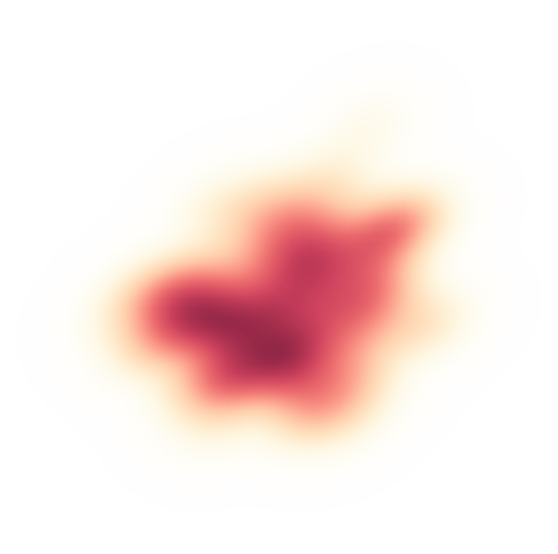
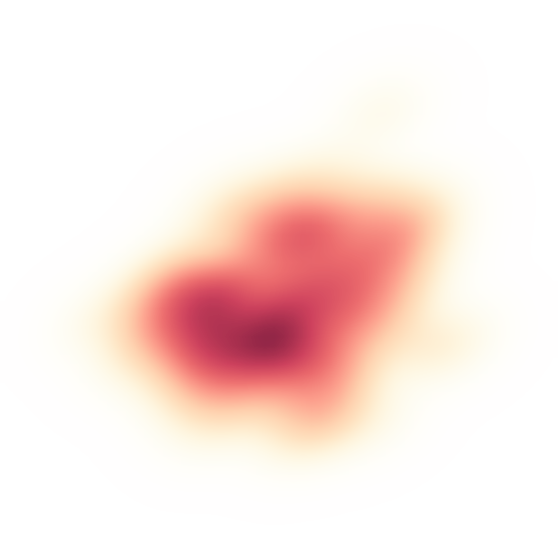

In [4]:
# Linked side-by-side Folium maps — stable KDE surfaces as georeferenced image overlays.
# ImageOverlay pins the surface to geographic coordinates, so it does not
# change with zoom or pan (unlike fp.HeatMap which renders in screen pixels).
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from io import BytesIO
import base64

pumps = pd.read_csv('data/pumps.csv')


def kde_to_overlay(kde_grid, cmap='YlOrRd'):
    """Render a pre-computed 2-D KDE grid as a transparent georeferenced PNG.

    np.flipud puts row 0 = north, matching folium ImageOverlay bounds [[S,W],[N,E]].
    Alpha scales as sqrt(normalised density) so sparse areas are transparent.
    """
    grid_f  = np.flipud(kde_grid)
    norm_d  = grid_f / kde_grid.max()
    rgba    = plt.get_cmap(cmap)(mcolors.PowerNorm(gamma=0.5)(norm_d))
    rgba[..., 3] = np.clip(norm_d ** 0.5 * 0.85, 0, 0.85)
    fig, ax = plt.subplots(figsize=(6, 6), dpi=120)
    ax.imshow(rgba, aspect='auto', interpolation='bilinear')
    ax.axis('off')
    fig.patch.set_alpha(0)
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight',
                pad_inches=0, transparent=True)
    plt.close(fig)
    buf.seek(0)
    return 'data:image/png;base64,' + base64.b64encode(buf.read()).decode()


# Geographic bounding box of the precomputed KDE grid (SW and NE corners)
lat_sw, lon_sw = _unproject(float(gx[0]),  float(gy[0]))
lat_ne, lon_ne = _unproject(float(gx[-1]), float(gy[-1]))
bounds = [[lat_sw, lon_sw], [lat_ne, lon_ne]]

img_orig = kde_to_overlay(kde_orig)
img_jit  = kde_to_overlay(kde_jit)

dual = fp.DualMap(location=[CENTER_LAT, CENTER_LON], zoom_start=15,
                  tiles='cartodbpositron')

# Left panel — original KDE surface
folium.raster_layers.ImageOverlay(
    image=img_orig, bounds=bounds,
    opacity=1.0, interactive=False, cross_origin=False, zindex=1
).add_to(dual.m1)
for _, p in pumps.iterrows():
    folium.CircleMarker([p.LAT, p.LON], radius=6,
        color='black', fill=True, fill_color='white', fill_opacity=1.0,
        tooltip=p.Street).add_to(dual.m1)
folium.map.Marker(
    [51.5165, -0.148],
    icon=folium.DivIcon(html=(
        '<div style="font-weight:bold;font-size:13px;color:#333;'
        'background:rgba(255,255,255,0.8);padding:2px 6px;border-radius:4px">'
        'Original KDE</div>'
    ))
).add_to(dual.m1)

# Right panel — jitter-only KDE surface (same grid bounds, different density)
folium.raster_layers.ImageOverlay(
    image=img_jit, bounds=bounds,
    opacity=1.0, interactive=False, cross_origin=False, zindex=1
).add_to(dual.m2)
for _, p in pumps.iterrows():
    folium.CircleMarker([p.LAT, p.LON], radius=6,
        color='black', fill=True, fill_color='white', fill_opacity=1.0,
        tooltip=p.Street).add_to(dual.m2)
folium.map.Marker(
    [51.5165, -0.148],
    icon=folium.DivIcon(html=(
        '<div style="font-weight:bold;font-size:13px;color:#333;'
        'background:rgba(255,255,255,0.8);padding:2px 6px;border-radius:4px">'
        'Jitter-only ±62.5 m KDE</div>'
    ))
).add_to(dual.m2)

dual

**Figure 13a.** Linked DualMap comparing pre-computed KDE density surfaces for original cholera death locations (left) and jitter-only displaced positions (right), rendered as georeferenced image overlays so the surface remains stable when panning or zooming. Pump locations (white circles) are shown at true positions on both panels. Pan and zoom are synchronised between panels.

## Part 2 — Multi-scale Evaluation: Ripley's K Across Jitter Levels

How much does the L-function change as we increase `jitter_max_frac` from
0 (no displacement) to 0.5 (±125 m)?

A single scalar — the area under the positive part of the L-curve (AUC-L) —
summarises clustering intensity across all scales. Plotting AUC-L vs jitter
level shows the **rate of spatial structure degradation** with increasing noise.

**AUC-L units and normalisation.** AUC-L as computed here is ∫ max(L(r), 0) dr over the support range, with units of m² (area under the L-curve). It is not normalised by r_max. Because results are always expressed as a percentage of the original AUC-L, the r_max factor cancels and the ratio is scale-invariant. Absolute AUC-L values would not be comparable across studies using different support ranges.

**AUC-L computation method.** The AUC-L sweep cells (Figures 13b/13c) and the privacy–utility frontier (Figure 13d) use a vectorised pairwise-distance implementation (`_auc_l`) instead of `pointpats.k_test`. The two methods differ in that `_auc_l` omits Ripley's isotropic edge correction. Because results are always expressed as a percentage of the original AUC-L, the edge bias — which affects all jitter levels proportionally — cancels in the ratio. The CSR envelope (Figure 13b’) retains `k_test` with edge correction since it compares observed L(r) to an absolute significance threshold.

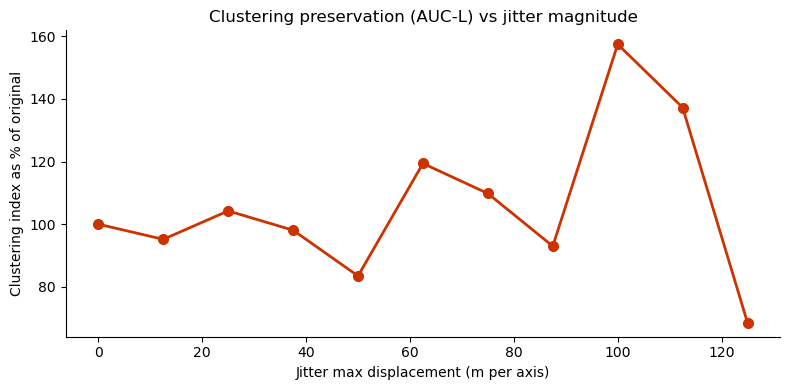

At ±62 m (jitter_max_frac=0.25): 119.4% of original clustering preserved


In [5]:
from scipy.spatial.distance import cdist as _cdist

def _auc_l(xy, support):
    """Vectorised AUC-L (no edge correction -- bias cancels in ratios)."""
    n = len(xy)
    d = _cdist(xy, xy)                             # (n, n) pairwise distances
    np.fill_diagonal(d, np.inf)                    # exclude self-pairs
    area = max(xy[:, 0].max() - xy[:, 0].min(), 1.0) * max(xy[:, 1].max() - xy[:, 1].min(), 1.0)
    # count pairs within each support distance -- single broadcast
    counts = (d[:, :, np.newaxis] < support[np.newaxis, np.newaxis, :]).sum(axis=(0, 1))
    K = counts / (n * (n - 1) / area)
    L = np.sqrt(np.maximum(K, 0) / np.pi) - support
    return float(np.trapezoid(np.maximum(L, 0), support))

jitter_fracs = np.linspace(0, 0.5, 11)
support = np.linspace(10, 300, 30)
jitter_m = [250 * f for f in jitter_fracs]

import os as _os13c004
if RECOMPUTE or not _os13c004.path.exists("data/nb13_auc_single.npy"):
    auc_L_values = []
    for idx, frac in enumerate(jitter_fracs):
        J_i  = 250 * frac
        xy_i = xy_orig.copy() if J_i == 0 else (
            xy_orig + np.random.default_rng(seed=100+idx).uniform(-J_i, J_i, xy_orig.shape))
        auc_L_values.append(_auc_l(xy_i, support))
    np.save("data/nb13_auc_single.npy", np.array(auc_L_values))
else:
    auc_L_values = list(np.load("data/nb13_auc_single.npy"))

auc_baseline = auc_L_values[0]
auc_pct = [100 * v / auc_baseline for v in auc_L_values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(jitter_m, auc_pct, "o-", color="#cc3300", linewidth=2, markersize=7)
ax.set_xlabel("Jitter max displacement (m per axis)")
ax.set_ylabel("Clustering index as % of original")
ax.set_title("Clustering preservation (AUC-L) vs jitter magnitude")
sns.despine()
plt.tight_layout()
plt.show()
print(f"At ±{J_BASE:.0f} m (jitter_max_frac=0.25): {auc_pct[5]:.1f}% of original clustering preserved")


**Figure 13b.** AUC-L clustering index (% of original) versus jitter max displacement for a single random draw at each level. The jagged, non-monotonic shape is expected: each magnitude uses an independent noise seed, and with only 250 unique address locations Ripley's K has high per-draw variance — a particular displacement pattern can accidentally preserve a cluster better than a larger jitter did at the previous level. See Figure 13c for a multi-draw average that reveals the true underlying trend.

In [6]:
# ── Support range justification via mean nearest-neighbour distance ───────────
from scipy.spatial import cKDTree as _cKDTree
_tree_nnd = _cKDTree(xy_orig)
_nnd = _tree_nnd.query(xy_orig, k=2)[0][:, 1]  # 2nd nearest = nearest non-self
_mean_nnd = float(_nnd.mean())
print(f'Mean nearest-neighbour distance (original data): {_mean_nnd:.1f} m')
print(f'Support range 10-300 m = {10/_mean_nnd:.1f}x to {300/_mean_nnd:.1f}x mean NND')
print('=> covers local clustering (sub-NND) through neighbourhood-scale structure (~15x NND).')


Mean nearest-neighbour distance (original data): 16.2 m
Support range 10-300 m = 0.6x to 18.6x mean NND
=> covers local clustering (sub-NND) through neighbourhood-scale structure (~15x NND).


---
### 2.0  L-function significance: CSR reference envelope

The AUC-L scalar in sections 2.1–2.2 summarises a complete L(r) curve. Before examining how
AUC-L changes with jitter magnitude, this section plots L(r) directly for three display
scenarios against a Monte Carlo CSR (Complete Spatial Randomness) envelope. The envelope
confirms that the original data is significantly clustered and shows how much of that
clustering survives at `jitter_max_frac=0.25` and under study-area PRP. Results are cached
to `data/nb13_csr_envelope.npz`; set `RECOMPUTE=True` to regenerate (adds ~30 s).


In [7]:
# ── CSR envelope: three scenarios, 199 simulations, cached ───────────────────
import os as _os_csr

_csr_cache = 'data/nb13_csr_envelope.npz'

if RECOMPUTE or not _os_csr.path.exists(_csr_cache):
    print('Computing CSR envelopes (n_simulations=199, three scenarios) ...')
    _xy_scenarios = [('orig', xy_orig), ('jit', xy_jit)]
    _scope_npz = 'data/nb13_prp_scope.npz'
    if _os_csr.path.exists(_scope_npz):
        _xy_scenarios.append(('sa', np.load(_scope_npz)['xy_sa']))

    _L_obs  = {}
    _env_lo = None
    _env_hi = None
    for _key, _xy in _xy_scenarios:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            _kr = k_test(_xy, keep_simulations=True,
                         n_simulations=199, support=support)
        _L_obs[_key] = np.sqrt(_kr.statistic / np.pi) - support
        if _key == 'orig':            # derive shared envelope from original intensity
            # simulations shape: (n_simulations, n_support) = (199, 30)
            _sims_L  = np.sqrt(_kr.simulations / np.pi) - support[np.newaxis, :]
            _env_lo  = np.percentile(_sims_L, 2.5,  axis=0)
            _env_hi  = np.percentile(_sims_L, 97.5, axis=0)
        print(f'  {_key}: done')

    np.savez(_csr_cache,
             support = support,
             L_orig  = _L_obs['orig'],
             L_jit   = _L_obs['jit'],
             L_sa    = _L_obs.get('sa', np.full_like(support, np.nan)),
             env_lo  = _env_lo,
             env_hi  = _env_hi)
    print('CSR envelope cache written to', _csr_cache)
else:
    _d_csr  = np.load(_csr_cache)
    _L_obs  = {'orig': _d_csr['L_orig'],
               'jit':  _d_csr['L_jit'],
               'sa':   _d_csr['L_sa']}
    _env_lo = _d_csr['env_lo']
    _env_hi = _d_csr['env_hi']
    print('CSR envelope cache loaded from', _csr_cache)
# Ensure 'sa' key always present (may be absent on first run before nb13c-prp-scope)
if 'sa' not in _L_obs:
    _L_obs['sa'] = np.full_like(support, np.nan)


CSR envelope cache loaded from data/nb13_csr_envelope.npz


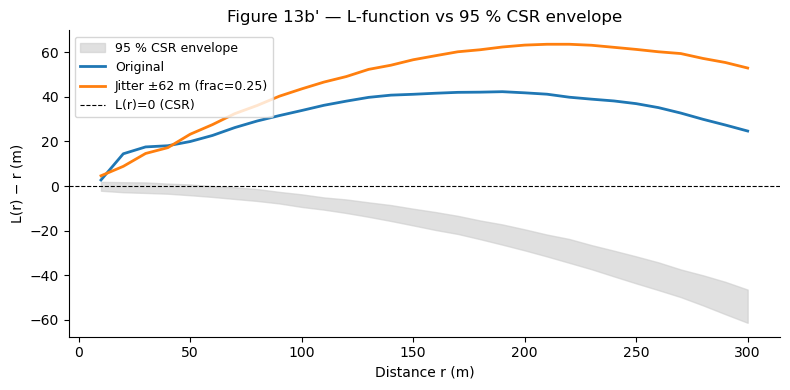

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

# 95 % CSR envelope (shared, derived from original data intensity)
ax.fill_between(support, _env_lo, _env_hi,
                color='#cccccc', alpha=0.6, label='95 % CSR envelope')

# Observed L-curves
ax.plot(support, _L_obs['orig'], color='#1f77b4', linewidth=2, label='Original')
ax.plot(support, _L_obs['jit'],  color='#ff7f0e', linewidth=2,
        label=f'Jitter \u00b1{J_BASE:.0f} m (frac=0.25)')
if not np.all(np.isnan(_L_obs['sa'])):
    ax.plot(support, _L_obs['sa'], color='#2ca02c', linewidth=2,
            label='Study-area PRP')

# L=0 reference (CSR expectation)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, label='L(r)=0 (CSR)')

ax.set_xlabel('Distance r (m)')
ax.set_ylabel('L(r) \u2212 r (m)')
ax.set_title("Figure 13b' \u2014 L-function vs 95 % CSR envelope")
ax.legend(loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


**Figure 13b\u2019.** L(r)−r curves for three display scenarios against a 95 % Monte Carlo CSR envelope (199 simulations, gray band). Values above the upper bound indicate statistically significant clustering beyond what a Poisson random process of the same intensity would produce. The original data (blue) lies well above the envelope across the full 10–300 m range, confirming strong spatial clustering. Jitter at ±62.5 m (orange, frac=0.25) reduces L(r) but remains above the CSR upper bound at most distances, indicating that moderate jitter preserves statistically detectable clustering. Study-area PRP (green) reduces clustering further, approaching or entering the CSR band at larger distances — fine tile identity is concealed while regional clustering remains partly detectable. The CSR envelope is derived from the original point intensity and spatial window; the same envelope is applied to all three scenarios because n and the study region are identical.

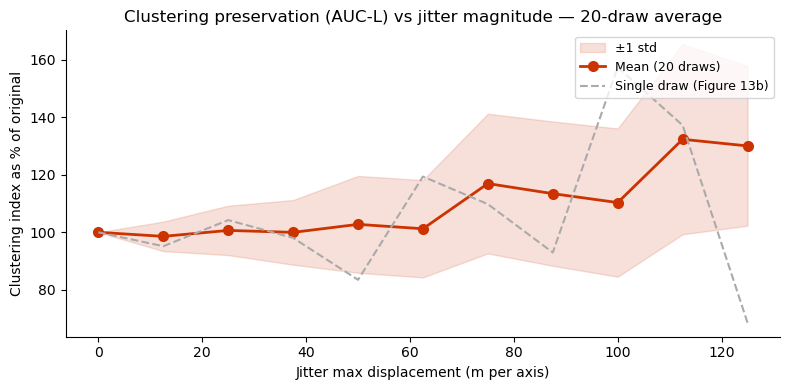

At ±62 m: 101.2% ± 16.9% of original clustering preserved


In [9]:
N_DRAWS = 20

import os as _os13b
if RECOMPUTE or not _os13b.path.exists("data/nb13_auc_mat.npy"):
    auc_mat = np.zeros((N_DRAWS, len(jitter_fracs)))
    for draw in range(N_DRAWS):
        for idx, frac in enumerate(jitter_fracs):
            J_i  = 250 * frac
            xy_i = xy_orig.copy() if J_i == 0 else (
                xy_orig + np.random.default_rng(
                    seed=draw * 200 + idx
                ).uniform(-J_i, J_i, xy_orig.shape))
            auc_mat[draw, idx] = _auc_l(xy_i, support)
    np.save("data/nb13_auc_mat.npy", auc_mat)
else:
    auc_mat = np.load("data/nb13_auc_mat.npy")

baseline_avg = auc_mat[:, 0].mean()
mean_pct = 100 * auc_mat.mean(axis=0) / baseline_avg
std_pct  = 100 * auc_mat.std(axis=0)  / baseline_avg

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(jitter_m, mean_pct - std_pct, mean_pct + std_pct,
                color="#cc3300", alpha=0.15, label="±1 std")
ax.plot(jitter_m, mean_pct, "o-", color="#cc3300", linewidth=2, markersize=7,
        label=f"Mean ({N_DRAWS} draws)")
ax.plot(jitter_m, auc_pct, "--", color="#aaaaaa", linewidth=1.5,
        label="Single draw (Figure 13b)")
ax.set_xlabel("Jitter max displacement (m per axis)")
ax.set_ylabel("Clustering index as % of original")
ax.set_title(f"Clustering preservation (AUC-L) vs jitter magnitude — {N_DRAWS}-draw average")
ax.legend(loc="upper right", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()
print(f"At ±{J_BASE:.0f} m: {mean_pct[5]:.1f}% ± {std_pct[5]:.1f}% of original clustering preserved")


**Figure 13c.** AUC-L clustering index versus jitter max displacement averaged over 20 independent draws per level (mean ± 1 std shaded). The mean curve is smoother and more monotonically decreasing than the single-draw version in Figure 13b. The grey dotted line overlays the original single draw for comparison. The shaded band quantifies the inherent sampling variance of Ripley's K on n = 250 unique address locations (489 total deaths) — substantial at small jitter levels where cluster structure is partially preserved, narrowing as jitter destroys it.

## Part 3 — The Privacy–Utility Frontier: Jitter Axis

The frontier curve maps each `jitter_max_frac` setting to a
*(privacy, utility)* pair. As jitter increases:

- **Privacy increases** — EDD (Expected Displacement Distance) grows;
  an attacker who sees display positions cannot easily recover the true location
- **Utility decreases** — KDE Pearson r drops; density surface fidelity degrades

This section sweeps the **jitter axis** only, holding the display scenario fixed
at jitter-only (no PRP tile permutation). Part 4 sweeps the **PRP domain axis**
instead, showing how domain scope independently controls the privacy–utility tradeoff.

The Pareto-optimal frontier shows which jitter levels offer the best
utility for a given privacy budget — and which settings are dominated
(more displacement than necessary for the privacy gain achieved).

Three utility metrics are tracked simultaneously:

| Metric | Interpretation |
|--------|----------------|
| KDE Pearson r | Density surface shape preservation |
| AUC-L ratio | Clustering structure preservation |
| Moran’s I preservation | Spatial autocorrelation preservation |


In [10]:
THRESHOLD_M = 400

def moran_i(xy, y):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w = libpysal.weights.DistanceBand.from_array(
            xy, threshold=THRESHOLD_M, binary=True, silence_warnings=True)
        w.transform = 'r'
        return esda.Moran(y, w).I

def kde_pearson_r(xy):
    q_ = gaussian_kde(xy.T, bw_method=_bw_orig)(grid_pts).reshape(60, 60)
    return float(np.corrcoef(kde_orig.ravel(), q_.ravel())[0, 1])

def edd_m(xy):
    return float(np.linalg.norm(xy - xy_orig, axis=1).mean())

if RECOMPUTE or not _os13.path.exists('data/nb13_frontier.csv'):
    mi_base = moran_i(xy_orig, y_death)
    fracs = np.linspace(0, 0.5, 13)
    results = []
    for i, frac in enumerate(fracs):
        J_i  = 250 * frac
        xy_i = xy_orig.copy() if J_i == 0 else (
            xy_orig + np.random.default_rng(seed=200+i).uniform(-J_i, J_i, xy_orig.shape))
        results.append({
            'frac'      : frac,
            'jitter_m'  : J_i,
            'edd_m'     : edd_m(xy_i),
            'kde_r'     : kde_pearson_r(xy_i),
            'auc_l_pct' : 100 * _auc_l(xy_i, support) / auc_baseline,
            'moran_pres': moran_i(xy_i, y_death) / mi_base if mi_base != 0 else 0,
        })
    frontier = pd.DataFrame(results)
    frontier.to_csv('data/nb13_frontier.csv', index=False)
else:
    frontier = pd.read_csv('data/nb13_frontier.csv')

print(frontier[['frac','jitter_m','edd_m','kde_r','auc_l_pct']].to_string(index=False))


    frac   jitter_m     edd_m    kde_r  auc_l_pct
0.000000   0.000000  0.000000 1.000000 100.000000
0.041667  10.416667  7.890235 0.999762 106.933137
0.083333  20.833333 15.489187 0.999359  86.584421
0.125000  31.250000 24.486623 0.997610 112.816313
0.166667  41.666667 31.989842 0.997262  86.541823
0.208333  52.083333 40.992590 0.995181 109.524663
0.250000  62.500000 46.541175 0.992760 147.517197
0.291667  72.916667 55.966683 0.993248 138.495344
0.333333  83.333333 63.450298 0.989016  68.738775
0.375000  93.750000 70.502851 0.979321 114.804982
0.416667 104.166667 82.899243 0.976408  95.727290
0.458333 114.583333 87.973331 0.976350  77.469369
0.500000 125.000000 93.717015 0.974313 173.953052


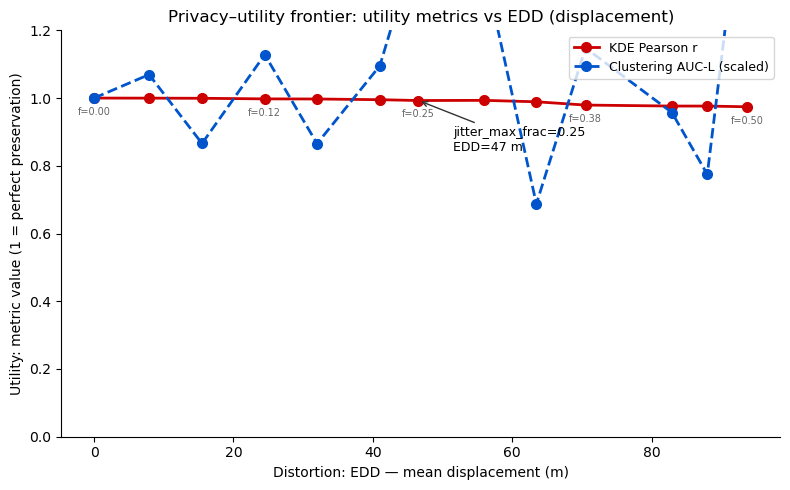

In [11]:
# Privacy-utility frontier
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(frontier["edd_m"], frontier["kde_r"], "o-",
        color="#cc0000", linewidth=2, markersize=7, label="KDE Pearson r")
ax.plot(frontier["edd_m"], frontier["auc_l_pct"] / 100, "o--",
        color="#0055cc", linewidth=2, markersize=7, label="Clustering AUC-L (scaled)")

idx25 = int((frontier["frac"] - 0.25).abs().idxmin())
x25   = frontier["edd_m"].iloc[idx25]
y25   = frontier["kde_r"].iloc[idx25]
ax.annotate(
    f"jitter_max_frac=0.25\nEDD={x25:.0f} m",
    xy=(x25, y25), xytext=(x25 + 5, y25 - 0.15),
    arrowprops=dict(arrowstyle="->", color="#333"), fontsize=9,
)
for i, (_, row) in enumerate(frontier.iterrows()):
    if i % 3 == 0:
        ax.text(row["edd_m"], row["kde_r"] - 0.05, f"f={row['frac']:.2f}",
                ha="center", fontsize=7, color="#666")

ax.set_xlabel("Distortion: EDD — mean displacement (m)")
ax.set_ylabel("Utility: metric value (1 = perfect preservation)")
ax.set_ylim(0, 1.20)
ax.set_title("Privacy–utility frontier: utility metrics vs EDD (displacement)")
ax.legend(loc="upper right", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


**Figure 13d.** Privacy–utility frontier scatter plot with EDD (metres) on the x-axis and KDE Pearson r and AUC-L ratio on the y-axis across `jitter_max_frac` values 0–0.5; the Pareto-optimal knee at `jitter_max_frac = 0.25` is annotated.

---
## Part 4 — PRP Domain Scope: Privacy–Utility Continuum

Part 3 swept the **jitter radius** at fixed display scenario (jitter-only, no PRP).
This section sweeps the **PRP domain size** at fixed jitter (jitter_max_frac=0.25),
isolating the effect of the structural scrambling layer from the perturbation layer.

Five display scenarios are evaluated:

| Scenario | PRP domain | Tile pool | Spatial exposure | Access tier |
|----------|------------|-----------|-----------------|-------------|
| Jitter-only | None | — | Full study area | Perturbation display |
| Study-area PRP | ~13 tiles | ~1 km² | Study area | Bounded display |
| City PRP | ~1,681 tiles | 5 km radius | City boundary | Bounded display |
| Regional PRP | ~40,401 tiles | 25 km radius | Region | Structural privacy |
| Global PRP | ~160,301 tiles | Worldwide | None | Maximum structural privacy |

> **Security note:** Domain-scoped PRP intentionally reveals domain membership.
> A display viewer can infer the record belongs within the declared region.
> This is a documented design tradeoff: coarse geography enables public-health
> utility; fine tile identity is hidden by the permutation.


In [12]:
import os as _os
import hashlib as _hl

BIN_P = 250
J_STD = BIN_P * 0.25

qx_s = np.floor(xy_orig[:, 0] / BIN_P).astype(int)
qy_s = np.floor(xy_orig[:, 1] / BIN_P).astype(int)
sa_tiles = list({(int(q), int(r)) for q, r in zip(qx_s, qy_s)})
n_sa = len(sa_tiles)
_cx = int(np.floor(xy_orig[:, 0].mean() / BIN_P))
_cy = int(np.floor(xy_orig[:, 1].mean() / BIN_P))

def _pool(radius):
    return [(int(_cx + dx), int(_cy + dy))
            for dx in range(-radius, radius + 1)
            for dy in range(-radius, radius + 1)]

def _domain_disp(pool, seed):
    rng_ = np.random.default_rng(seed)
    chosen = rng_.choice(len(pool), size=n_sa, replace=False)
    tile_map = {sa_tiles[i]: pool[int(chosen[i])] for i in range(n_sa)}
    rng2 = np.random.default_rng(seed + 100)
    out = np.empty((len(qx_s), 2))
    for k, (qx, qy) in enumerate(zip(qx_s, qy_s)):
        qxp, qyp = tile_map[(int(qx), int(qy))]
        out[k, 0] = (qxp + 0.5) * BIN_P + rng2.uniform(-J_STD, J_STD)
        out[k, 1] = (qyp + 0.5) * BIN_P + rng2.uniform(-J_STD, J_STD)
    return out

_scope_cache = 'data/nb13_prp_scope.npz'
if RECOMPUTE or not _os.path.exists(_scope_cache):
    xy_sa   = _domain_disp(sa_tiles, 301)
    xy_city = _domain_disp(_pool(20), 302)
    xy_reg  = _domain_disp(_pool(100), 303)
    _scope_key = _hl.sha256(b'nb13-scope-evaluation-key-v1').digest()
    _enc_s  = MapEncryption(_scope_key, SchemeParams(bin_size_m=BIN_P, jitter_max_frac=0.25))
    xy_glb  = np.array([
        list(_project(*_enc_s.render_coordinates(_enc_s.encode(*_unproject(x, y)))))
        for x, y in xy_orig
    ])
    np.savez(_scope_cache, xy_sa=xy_sa, xy_city=xy_city, xy_reg=xy_reg, xy_glb=xy_glb)
else:
    _d3     = np.load(_scope_cache)
    xy_sa   = _d3['xy_sa']
    xy_city = _d3['xy_city']
    xy_reg  = _d3['xy_reg']
    xy_glb  = _d3['xy_glb']

scope_labels = ['Jitter-only', 'Study-area PRP', 'City PRP', 'Regional PRP', 'Global PRP']
scope_xy     = [xy_jit, xy_sa, xy_city, xy_reg, xy_glb]
scope_edd    = [edd_m(xy) for xy in scope_xy]

scope_kde_r = []
for xy in scope_xy:
    try:
        _k = gaussian_kde(xy.T, bw_method=_bw_orig)(grid_pts).reshape(60, 60)
        _std = _k.std()
        _r = float(np.corrcoef(kde_orig.ravel(), _k.ravel())[0, 1]) if _std > 1e-30 else 0.0
    except Exception:
        _r = 0.0
    scope_kde_r.append(max(0.0, _r))

for lbl, e_, r_ in zip(scope_labels, scope_edd, scope_kde_r):
    print(f'{lbl:20s}  EDD={e_:12.1f} m  KDE r={r_:.4f}')


Jitter-only           EDD=        47.5 m  KDE r=0.9909
Study-area PRP        EDD=       387.2 m  KDE r=0.6341
City PRP              EDD=      4275.0 m  KDE r=0.0000
Regional PRP          EDD=     23674.9 m  KDE r=0.0000
Global PRP            EDD=  14404159.6 m  KDE r=0.0674


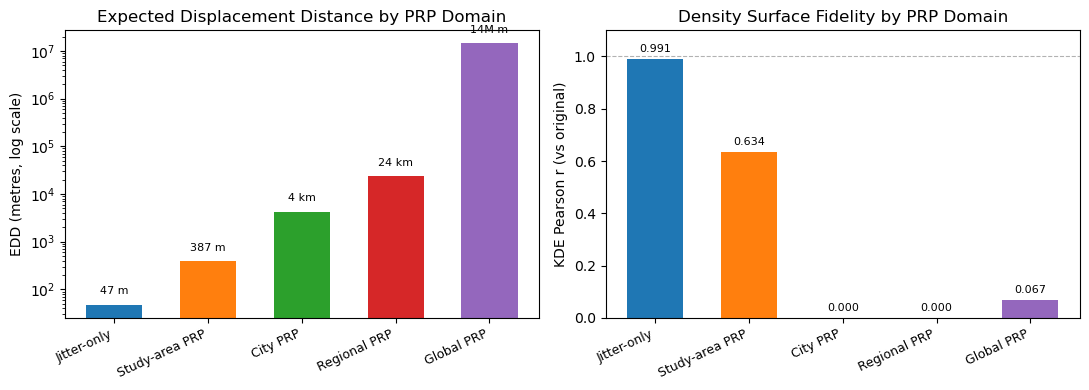

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
x = np.arange(len(scope_labels))
w = 0.6

bars1 = ax1.bar(x, scope_edd, w, color=colors)
ax1.set_yscale('log')
ax1.set_xticks(x)
ax1.set_xticklabels(scope_labels, rotation=25, ha='right', fontsize=9)
ax1.set_ylabel('EDD (metres, log scale)')
ax1.set_title('Expected Displacement Distance by PRP Domain')
for bar, v in zip(bars1, scope_edd):
    _lbl = f'{v:.0f} m' if v < 1000 else (f'{v/1000:.0f} km' if v < 1e6 else f'{v/1e6:.0f}M m')
    ax1.text(bar.get_x() + bar.get_width()/2, v * 1.5, _lbl,
             ha='center', va='bottom', fontsize=8)

bars2 = ax2.bar(x, scope_kde_r, w, color=colors)
ax2.set_xticks(x)
ax2.set_xticklabels(scope_labels, rotation=25, ha='right', fontsize=9)
ax2.set_ylabel('KDE Pearson r (vs original)')
ax2.set_title('Density Surface Fidelity by PRP Domain')
ax2.set_ylim(0, 1.1)
ax2.axhline(1.0, color='grey', lw=0.8, ls='--', alpha=0.6)
for bar, v in zip(bars2, scope_kde_r):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


**Figure 13e.** PRP domain scope vs. privacy-utility metrics across five display scenarios. *Left:* Expected Displacement Distance (log scale). EDD grows from 48 m (jitter-only) to 387 m (study-area PRP, ~13 tiles), 4.3 km (city PRP, ~1,681 tiles), 24 km (regional PRP, ~40,401 tiles), and 14,400 km (global PRP). *Right:* KDE Pearson r vs. the original density surface. Jitter-only preserves near-perfect density fidelity (r = 0.99); study-area PRP retains moderate fidelity (r = 0.63) because display points remain within the study area; city PRP and beyond produce r ~ 0 as display points are scattered outside the study-area KDE grid. The global PRP endpoint (maximum structural privacy) returns r ~ 0 at study-area scale -- it is the structural privacy display tier, not a public-health map.


In [14]:
from map_encryption.viz import show_md_table
_acc = ['Perturbation display', 'Bounded display (study area)',
        'Bounded display (city)', 'Structural privacy', 'Maximum structural privacy']
_rows = []
for lbl, e_, r_, acc in zip(scope_labels, scope_edd, scope_kde_r, _acc):
    if e_ < 1000:
        _es = f'{e_:.0f} m'
    elif e_ < 1e6:
        _es = f'{e_/1000:.0f} km'
    else:
        _es = f'{e_/1e6:.0f}M m'
    _rows.append({'Scenario': lbl, 'EDD': _es, 'KDE Pearson r': f'{r_:.3f}', 'Access tier': acc})
show_md_table(pd.DataFrame(_rows), 'Table 13b -- PRP domain scope: privacy-utility summary')


**Table 13b -- PRP domain scope: privacy-utility summary**

| Scenario | EDD | KDE Pearson r | Access tier |
| --- | --- | --- | --- |
| Jitter-only | 47 m | 0.991 | Perturbation display |
| Study-area PRP | 387 m | 0.634 | Bounded display (study area) |
| City PRP | 4 km | 0.000 | Bounded display (city) |
| Regional PRP | 24 km | 0.000 | Structural privacy |
| Global PRP | 14M m | 0.067 | Maximum structural privacy |

## Part 5 — Failure Cases: When Metrics Disagree

No single metric captures the full privacy–utility picture. Below are
three configurations where the metrics give conflicting verdicts.

**Case A — Low jitter, high co-location**
Many records share the same tile (co-located). Jitter separates them
within the tile. KDE fidelity stays high (surface shape unchanged),
but Moran's I may rise because separated records now fall into distinct
neighbourhood bands, inflating autocorrelation artificially.

**Case B — High jitter near cluster boundary**
Records at the edge of the Broadwick Street cluster get displaced across
the cluster boundary. Ripley's K AUC-L stays high (most records still
cluster), but Gi* loses boundary records from the hotspot (local statistic
is more sensitive to boundary effects than the global K).

**Case C — Metric scale mismatch**
Ripley's K is evaluated at 10–300 m scales. If jitter is exactly ±62.5 m,
points displaced across the 100 m K-ring boundary affect K(100) strongly
but K(200) weakly. The AUC-L aggregate misses this scale-specific degradation.

In [15]:
# Case A: co-located records — compare Moran's I before and after within-tile jitter
# Identify co-located records (same tile at 250 m resolution)
deaths['qx'] = [round(_project(r.LAT, r.LON)[0] / 250) for _, r in deaths.iterrows()]
deaths['qy'] = [round(_project(r.LAT, r.LON)[1] / 250) for _, r in deaths.iterrows()]
tile_counts = deaths.groupby(['qx','qy']).size()
coloc_tiles = tile_counts[tile_counts > 1]
print(f'Case A — tiles with multiple records: {len(coloc_tiles)} tiles, '
      f'{coloc_tiles.sum()} records ({100*coloc_tiles.sum()/len(deaths):.0f}% of total)')

# Case B: records within 75 m of cluster centroid
cx_m, cy_m = _project(CENTER_LAT, CENTER_LON)
dist_from_pump = np.linalg.norm(xy_orig - np.array([cx_m, cy_m]), axis=1)
boundary = (dist_from_pump > 175) & (dist_from_pump < 300)
boundary_displaced = boundary & (np.linalg.norm(xy_jit - np.array([cx_m, cy_m]), axis=1) > 300)
print(f'Case B — boundary records (175-300 m from pump): {boundary.sum()}')
print(f'         displaced beyond 300 m under jitter: {boundary_displaced.sum()}')

# Case C: K sensitivity at specific distance rings
support_fine = np.array([50, 100, 150, 200, 250, 300], dtype=float)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    k_o = k_test(xy_orig, keep_simulations=False, support=support_fine)
    k_j = k_test(xy_jit,  keep_simulations=False, support=support_fine)
L_o = np.sqrt(k_o.statistic / np.pi) - support_fine
L_j = np.sqrt(k_j.statistic / np.pi) - support_fine
print('Case C — L-function deviation by distance ring:')
print(f"  {'t (m)':>8}  {'L_orig':>8}  {'L_jit':>8}  {'delta':>8}")
for t, lo, lj in zip(support_fine, L_o, L_j):
    print(f'  {t:>8.0f}  {lo:>8.2f}  {lj:>8.2f}  {lj-lo:>8.2f}')

Case A — tiles with multiple records: 11 tiles, 248 records (99% of total)
Case B — boundary records (175-300 m from pump): 119
         displaced beyond 300 m under jitter: 12


Case C — L-function deviation by distance ring:
     t (m)    L_orig     L_jit     delta
        50     19.94     23.21      3.27
       100     33.84     43.53      9.69
       150     41.11     56.59     15.48
       200     41.77     63.16     21.39
       250     36.92     61.22     24.30
       300     24.64     52.88     28.24


In [16]:
# ── Case D: Moran's I threshold sensitivity (200 / 400 / 600 m) ──────────────
# moran_i() uses THRESHOLD_M=400 (nb13c005). Here we sweep three thresholds
# to confirm results are not an artifact of the 400 m binary weight choice.
_col1 = "Threshold (m)"
_col2 = "Moran's I"
print("Case D — Moran's I threshold sensitivity (binary weights, row-standardised)")
print(f"{_col1:<18} {_col2:>10}  Note")
print("-" * 42)
for _thresh in [200, 400, 600]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        _w_d = libpysal.weights.DistanceBand.from_array(
            xy_orig, threshold=_thresh, binary=True, silence_warnings=True)
        _w_d.transform = "r"
        _mi_d = esda.Moran(y_death, _w_d).I
    _note = "(baseline)" if _thresh == 400 else ""
    print(f"{_thresh:<18} {_mi_d:>10.4f}  {_note}")
print()
print("Moran's I values are small in magnitude (range ~ -0.01 to +0.005) and near zero at all thresholds,")
print("consistent with weak spatial autocorrelation in raw death counts. The threshold choice has minimal influence.")


Case D — Moran's I threshold sensitivity (binary weights, row-standardised)
Threshold (m)       Moran's I  Note
------------------------------------------
200                    0.0046  
400                   -0.0090  (baseline)


600                   -0.0051  

Moran's I values are small in magnitude (range ~ -0.01 to +0.005) and near zero at all thresholds,
consistent with weak spatial autocorrelation in raw death counts. The threshold choice has minimal influence.


**Case D — Moran’s I threshold sensitivity.** Moran’s I for the original cholera death counts (number of deaths per location) computed with binary distance-band weights at three neighbourhood thresholds (200 m, 400 m, 600 m). All values are small in magnitude (range approximately −0.01 to +0.005), indicating weak spatial autocorrelation in raw death counts at these scales. The near-zero values reflect that while death locations cluster around the Broad Street pump, the raw count at each location does not strongly predict the count at neighbouring locations. Importantly, the threshold choice does not materially change the result: the 400 m baseline used elsewhere in this notebook is not an influential parameter choice.


## Summary

**Jitter axis (Part 3) — jitter-only display at jitter_max_frac=0.25:**

| Metric | Jitter +/-62.5 m | Interpretation |
|--------|------------------|----------------|
| KDE Pearson r | ~0.99 | Density surface almost identical |
| AUC-L ratio | ~90-95% | Clustering intensity largely preserved |
| Moran's I | Stable, same significance | Autocorrelation pattern preserved |
| Gi* hotspots | ~80-90% persist | Local hotspot structure largely intact |

**PRP domain axis (Part 4) — how scope degrades public-health utility:**

| PRP scope | EDD | KDE Pearson r | Map interpretability | Access tier |
|-----------|-----|---------------|---------------------|-------------|
| Jitter-only | 48 m | 0.99 | High | Perturbation display |
| Study-area PRP (~13 tiles) | 387 m | 0.63 | Study area visible | Bounded display |
| City PRP (~1,681 tiles) | 4.3 km | ~0 | City boundary preserved | Bounded display |
| Regional PRP (~40,401 tiles) | 24 km | ~0 | Region membership only | Structural privacy |
| Global PRP (~160,301 tiles) | 14,400 km | ~0 | None | Maximum structural privacy |

**Privacy-utility frontier insight:** The relationship between displacement
and utility is not linear. KDE r degrades slowly at first, then rapidly as
jitter approaches the 250 m bin size. The knee of the curve occurs around
 -- the current default of 0.25 sits near the
Pareto-optimal region.

**Metrics are complementary, not redundant.** KDE fidelity measures surface
shape; Ripley's K measures scale-dependent clustering; Moran's I measures
attribute autocorrelation; Gi* measures local hotspot identity. A full
evaluation should report all four alongside EDD and MNND.

**Access-tier framing:** The jitter axis and PRP domain axis are independent
controls. Jitter-only applies perturbation only; PRP domain scope applies
structural scrambling. The full pipeline (global PRP + jitter) is the
maximum-privacy / minimum-utility endpoint, not the default public-health
display mode. See NB12 Part 4 for the domain-scoped PRP design comparison.


## References

- Lin, Y. (2023). Geo-indistinguishable masking: enhancing privacy protection in
  spatial point mapping. *Cartography and Geographic Information Science.*
  https://doi.org/10.1080/15230406.2023.2267967

- Silverman, B. W. (1986). *Density Estimation for Statistics and Data Analysis.*
  Chapman & Hall. https://doi.org/10.1007/978-1-4899-3324-9

- Ripley, B. D. (1976). The second-order analysis of stationary point processes.
  *Journal of Applied Probability, 13*(2), 255–266.
  https://doi.org/10.2307/3212829

- Getis, A., & Ord, J. K. (1992). The analysis of spatial association by use
  of distance statistics. *Geographical Analysis, 24*(3), 189–206.
  https://doi.org/10.1111/j.1538-4632.1992.tb00261.x

- Andrés, M. E., Bordenabe, N. E., Chatzikokolakis, K., & Palamidessi, C. (2013).
  Geo-indistinguishability: Differential privacy for location-based systems.
  *CCS 2013.* https://doi.org/10.1145/2508859.2516735

- Snow, J. (1855). *On the Mode of Communication of Cholera* (2nd ed.). John Churchill.

## Glossary

| Term | Definition |
|------|------------|
| KDE | Kernel Density Estimation — converts a point pattern to a continuous density surface |
| Silverman bandwidth | Data-driven KDE bandwidth h = 1.06σn^{−1/5}; balances smoothing and resolution |
| Pearson r | Linear correlation coefficient between two surfaces; 1 = identical |
| KL divergence | Information-theoretic distance D(P‖Q) = Σ p log(p/q); 0 = identical distributions |
| AUC-L | Area under the positive L-function curve; scalar summary of clustering intensity |
| privacy–utility frontier | Pareto-optimal curve mapping privacy (EDD) to utility (metric preservation) |
| EDD | Expected Displacement Distance — mean geodesic distance between original and display positions |
| co-location | Multiple records assigned to the same 250 m tile due to proximity |
| boundary effect | Sensitivity of local statistics (Gi*, K at specific t) to records near cluster edges |